# 🦺 Construction Safety Monitor - Complete Training Pipeline

This notebook focuses on the Pose + ResNet architecture for the Construction Safety Monitor:
1. **Phase 2**: Generating pose-derived anatomical Ground Truth ROIs using `YOLOv8-Pose` to match inference behavior.
2. **Phase 3**: Training MobileNetV3 specific classification heads (`helmet`, `vest`, `gloves`, `boots`, `goggles`) over the realistic ROIs.
3. **Phase 4**: Visualizing end-to-end inference over a test image.

In [4]:
!pip install ultralytics opencv-python-headless matplotlib seaborn pandas pillow pyyaml torch torchvision --quiet

import ultralytics
from ultralytics import YOLO
ultralytics.checks()


Ultralytics 8.3.171  Python-3.12.10 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
Setup complete  (22 CPUs, 15.5 GB RAM, 58.9/469.2 GB disk)


In [1]:
import os
from pathlib import Path
import yaml

USE_DRIVE = False

if USE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    DATASET_ROOT = Path('/content/drive/MyDrive/YoloDataset')
else:
    DATASET_ROOT = Path('YoloDataset')

assert DATASET_ROOT.exists(), f'Dataset not found at {DATASET_ROOT}'
print(f'Dataset found at: {DATASET_ROOT}')

MODEL_DIR = Path('construction_safety/models')
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Setup temporary absolute dataset path for YOLOv8 
DATA_YAML = Path('dataset_abs.yaml')
CLASS_NAMES = ['helmet','gloves','vest','boots','goggles','none','Person',
               'no_helmet','no_goggle','no_gloves','no_boots']

dataset_config = {
    'path': str(DATASET_ROOT.resolve()),
    'train': 'images/train',
    'val':   'images/val',
    'test':  'images/test',
    'nc': 11,
    'names': {i: n for i, n in enumerate(CLASS_NAMES)},
}

with open(DATA_YAML, 'w') as f:
    yaml.dump(dataset_config, f, default_flow_style=False)


Dataset found at: YoloDataset


## Phase 2: Pose-Based ROI Extractor
We use YOLOv8-pose to locate keypoints on each worker from our Ground Truth labels, deriving anatomical bounding boxes (Head, Torso, Wrists) and matching their IoU against actual Ground Truth target PPE boxes to label them realistically for classifiers.

In [2]:
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class BBox:
    def __init__(self, x1, y1, x2, y2):
        self.x1, self.y1, self.x2, self.y2 = x1, y1, x2, y2
        
def compute_iou(boxA, boxB):
    xA = max(boxA.x1, boxB.x1)
    yA = max(boxA.y1, boxB.y1)
    xB = min(boxA.x2, boxB.x2)
    yB = min(boxA.y2, boxB.y2)
    interArea = max(0, xB - xA) * max(0, yB - yA)
    if interArea == 0: return 0.0
    boxAArea = (boxA.x2 - boxA.x1) * (boxA.y2 - boxA.y1)
    boxBArea = (boxB.x2 - boxB.x1) * (boxB.y2 - boxB.y1)
    return interArea / float(boxAArea + boxBArea - interArea)

class PoseROIBuilder:
    def __init__(self, dataset_dir, split='train', roi_type='helmet'):
        self.dataset_dir = Path(dataset_dir)
        self.roi_type = roi_type
        self.split = split
        self.pose_model = YOLO('yolov8n-pose.pt')
        self.samples = []
        self._build()
        
    def _build(self):
        print(f"Building Pose-derived ROIs for {self.roi_type} [{self.split}]...")
        PPE_CLASSES = {
            'helmet': {'present': 0, 'absent': 7},
            'vest':   {'present': 2, 'absent': None},
            'gloves': {'present': 1, 'absent': 9},
            'boots':  {'present': 3, 'absent': 10},
            'goggles':{'present': 4, 'absent': 8}
        }
        
        c_map = PPE_CLASSES.get(self.roi_type, {})
        present_cls = c_map.get('present')
        absent_cls = c_map.get('absent')
        
        img_dir = self.dataset_dir / 'images' / self.split
        lbl_dir = self.dataset_dir / 'labels' / self.split
        
        for img_path in list(img_dir.glob('*.jpg')):
            lbl_path = lbl_dir / img_path.with_suffix('.txt').name
            if not lbl_path.exists(): continue
            
            img = cv2.imread(str(img_path))
            if img is None: continue
            h, w = img.shape[:2]
            
            persons, present_boxes, absent_boxes = [], [], []
            for line in lbl_path.read_text().splitlines():
                parts = line.strip().split()
                if len(parts) < 5: continue
                cls_id = int(parts[0])
                cx, cy, bw, bh = (float(p) for p in parts[1:5])
                x1, y1 = (cx - bw/2)*w, (cy - bh/2)*h
                x2, y2 = (cx + bw/2)*w, (cy + bh/2)*h
                
                if cls_id == 6: persons.append(BBox(x1, y1, x2, y2))
                elif cls_id == present_cls: present_boxes.append(BBox(x1, y1, x2, y2))
                elif cls_id == absent_cls: absent_boxes.append(BBox(x1, y1, x2, y2))
                
            for pbox in persons:
                px1, py1, px2, py2 = int(max(0, pbox.x1)), int(max(0, pbox.y1)), int(min(w, pbox.x2)), int(min(h, pbox.y2))
                worker_crop = img[py1:py2, px1:px2]
                if worker_crop.size == 0: continue
                
                res = self.pose_model.predict(worker_crop, verbose=False, device='cpu')[0]
                if res.keypoints is None or len(res.keypoints.data) == 0: continue
                kp = res.keypoints.data[0].cpu().numpy()
                
                target_roi = None
                
                if self.roi_type == 'helmet':
                    head_kps = [k for k in kp[:5] if k[2] > 0.5]
                    if head_kps:
                        cx = np.mean([k[0] for k in head_kps]) + px1
                        cy = np.mean([k[1] for k in head_kps]) + py1
                        head_size = 40.0
                        if kp[5][2] > 0.5 and kp[6][2] > 0.5:
                            shoulder_width = abs(kp[6][0] - kp[5][0])
                            head_size = max(30.0, shoulder_width * 0.45)
                        
                        rx1 = cx - head_size * 1.4
                        rx2 = cx + head_size * 1.4
                        ry1 = cy - head_size * 2.2
                        ry2 = cy + head_size * 1.0
                        target_roi = BBox(rx1, ry1, rx2, ry2)
                        
                elif self.roi_type == 'vest':
                    l_sh, r_sh = kp[5], kp[6]
                    l_hip, r_hip = kp[11], kp[12]
                    if all(k[2] > 0.5 for k in [l_sh, r_sh, l_hip, r_hip]):
                        pad = 10
                        rx1 = min(l_sh[0], r_sh[0], l_hip[0], r_hip[0]) + px1 - pad
                        ry1 = min(l_sh[1], r_sh[1]) + py1 - pad
                        rx2 = max(l_sh[0], r_sh[0], l_hip[0], r_hip[0]) + px1 + pad
                        ry2 = max(l_hip[1], r_hip[1]) + py1 + pad
                        target_roi = BBox(rx1, ry1, rx2, ry2)
                        
                elif self.roi_type == 'gloves':
                    # Pick the highest confidence wrist
                    w_kp = kp[9] if kp[9][2] > kp[10][2] else kp[10]
                    if w_kp[2] > 0.5:
                        r = 30.0
                        target_roi = BBox(w_kp[0]+px1-r, w_kp[1]+py1-r, w_kp[0]+px1+r, w_kp[1]+py1+r)
                        
                elif self.roi_type == 'boots':
                    # Pick highest confidence ankle
                    a_kp = kp[15] if kp[15][2] > kp[16][2] else kp[16]
                    if a_kp[2] > 0.5:
                        bw, bhu, bhd = 35.0, 45.0, 20.0
                        target_roi = BBox(a_kp[0]+px1-bw, a_kp[1]+py1-bhu, a_kp[0]+px1+bw, a_kp[1]+py1+bhd)
                        
                elif self.roi_type == 'goggles':
                    eyes = [k for k in (kp[1], kp[2], kp[0]) if k[2] > 0.5]
                    if len(eyes) >= 1:
                        cx_eye = sum(k[0] for k in eyes) / len(eyes) + px1
                        cy_eye = sum(k[1] for k in eyes) / len(eyes) + py1
                        g_size = max(15.0, 24.0)
                        target_roi = BBox(cx_eye-g_size*1.5, cy_eye-g_size*0.8, cx_eye+g_size*1.5, cy_eye+g_size*1.2)
                        
                if target_roi is None: continue
                
                label = None
                for gt in present_boxes:
                    if compute_iou(target_roi, gt) > 0.05:
                        label = 2; break
                if label is None:
                    for gt in absent_boxes:
                        if compute_iou(target_roi, gt) > 0.05:
                            label = 0; break
                            
                if label is None and absent_cls is None:
                    label = 0  # Default to absent for vest/harness since no bounding box exists
                elif label is None:
                    continue
                
                tx1, ty1 = int(max(0, target_roi.x1)), int(max(0, target_roi.y1))
                tx2, ty2 = int(min(w, target_roi.x2)), int(min(h, target_roi.y2))
                
                roi_img = img[ty1:ty2, tx1:tx2]
                if roi_img.size > 0:
                    self.samples.append((roi_img, label))
                    
        print(f"  → Extracted {len(self.samples)} valid samples for {self.roi_type}.")
        
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        return self.samples[idx][0], self.samples[idx][1]

## Phase 3: Train ResNet Head Classifiers
We extract realistically scaled training/validation sets through the Pose Builder for each class, and loop through training each individualized ResNet-18 classifier.

In [5]:
import torch.nn as nn
import torch.optim as optim
from torchvision.models import mobilenet_v3_small

class TorchCropDataset(Dataset):
    def __init__(self, base_ds, transform=None):
        self.base_ds = base_ds
        self.transform = transform
        
    def __len__(self): return len(self.base_ds)
    def __getitem__(self, idx):
        img, label = self.base_ds[idx]
        rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        if self.transform:
            rgb = self.transform(rgb)
        return rgb, torch.tensor(label, dtype=torch.long)

def train_head(head_name):
    print(f"\n{'='*50}\nTraining {head_name.upper()} Head classifier\n{'='*50}")
    train_ds = PoseROIBuilder(DATASET_ROOT, split='train', roi_type=head_name)
    val_ds = PoseROIBuilder(DATASET_ROOT, split='val', roi_type=head_name)
    
    if len(train_ds) == 0:
        print(f"No samples for {head_name}, skipping.")
        return

    transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    val_transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    train_loader = DataLoader(TorchCropDataset(train_ds, transform), batch_size=32, shuffle=True)
    val_loader = DataLoader(TorchCropDataset(val_ds, val_transform), batch_size=32, shuffle=False)
    
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model = mobilenet_v3_small(weights='IMAGENET1K_V1')
    in_features = model.classifier[3].in_features
    model.classifier[3] = nn.Linear(in_features, 3)
    model = model.to(device)
    
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)
    criterion = nn.CrossEntropyLoss()
    
    best_val_acc = 0.0
    epochs = 30
    
    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            out = model(imgs)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            
        scheduler.step()
        
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                preds = model(imgs).argmax(dim=1)
                correct += (preds == labels).sum().item()
                total += len(labels)
                
        val_acc = correct / total if total > 0 else 0.0
        avg_loss = total_loss / len(train_loader)
        
        if epoch % 5 == 0 or epoch == 1:
            print(f"  Epoch {epoch:2d}/{epochs} | Loss: {avg_loss:.4f} | Val Acc: {val_acc:.4f}")
            
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), MODEL_DIR / f"{head_name}_head.pth")
            
    print(f"Completed {head_name.upper()}. Best Val Acc: {best_val_acc:.4f}")

# Run training for all PPE class heads
for head in ['helmet', 'vest', 'gloves', 'boots', 'goggles']:
    train_head(head)

print("\nAll Training Phases Completed Successfully!")


Training HELMET Head classifier
Building Pose-derived ROIs for helmet [train]...
  → Extracted 1281 valid samples for helmet.
Building Pose-derived ROIs for helmet [val]...
  → Extracted 177 valid samples for helmet.
  Epoch  1/30 | Loss: 0.4714 | Val Acc: 0.9153
  Epoch  5/30 | Loss: 0.0248 | Val Acc: 0.9774
  Epoch 10/30 | Loss: 0.0047 | Val Acc: 0.9718
  Epoch 15/30 | Loss: 0.0437 | Val Acc: 0.9774
  Epoch 20/30 | Loss: 0.0335 | Val Acc: 0.9718
  Epoch 25/30 | Loss: 0.0167 | Val Acc: 0.9718
  Epoch 30/30 | Loss: 0.0139 | Val Acc: 0.9718
Completed HELMET. Best Val Acc: 0.9774

Training VEST Head classifier
Building Pose-derived ROIs for vest [train]...
  → Extracted 1073 valid samples for vest.
Building Pose-derived ROIs for vest [val]...
  → Extracted 135 valid samples for vest.
  Epoch  1/30 | Loss: 0.5747 | Val Acc: 0.8000
  Epoch  5/30 | Loss: 0.1048 | Val Acc: 0.8963
  Epoch 10/30 | Loss: 0.0301 | Val Acc: 0.8963
  Epoch 15/30 | Loss: 0.0186 | Val Acc: 0.8963
  Epoch 20/30 | Lo

## Phase 4: Full Pipeline Inference Visualization
In this final step, we execute a comprehensive end-to-end visualization of the system on a test image:
1. Compute YOLOv8-Pose to identify Workers and 17 COCO Keypoints.
2. Mathematically map precise regions (helmet, vest, gloves, boots, goggles) over the image.
3. Evaluate those mapped crops individually against the MobileNetV3-Small `.pth` files generated in Phase 3.
4. Render the safety statuses prominently on screen.

In [9]:
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [13]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

Loading MobileNet Classifiers...


C:\Users\UGuruparan\AppData\Local\Temp\ipykernel_28156\3170117025.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  m.load_state_dict(torch.load(pth, map_location=device)

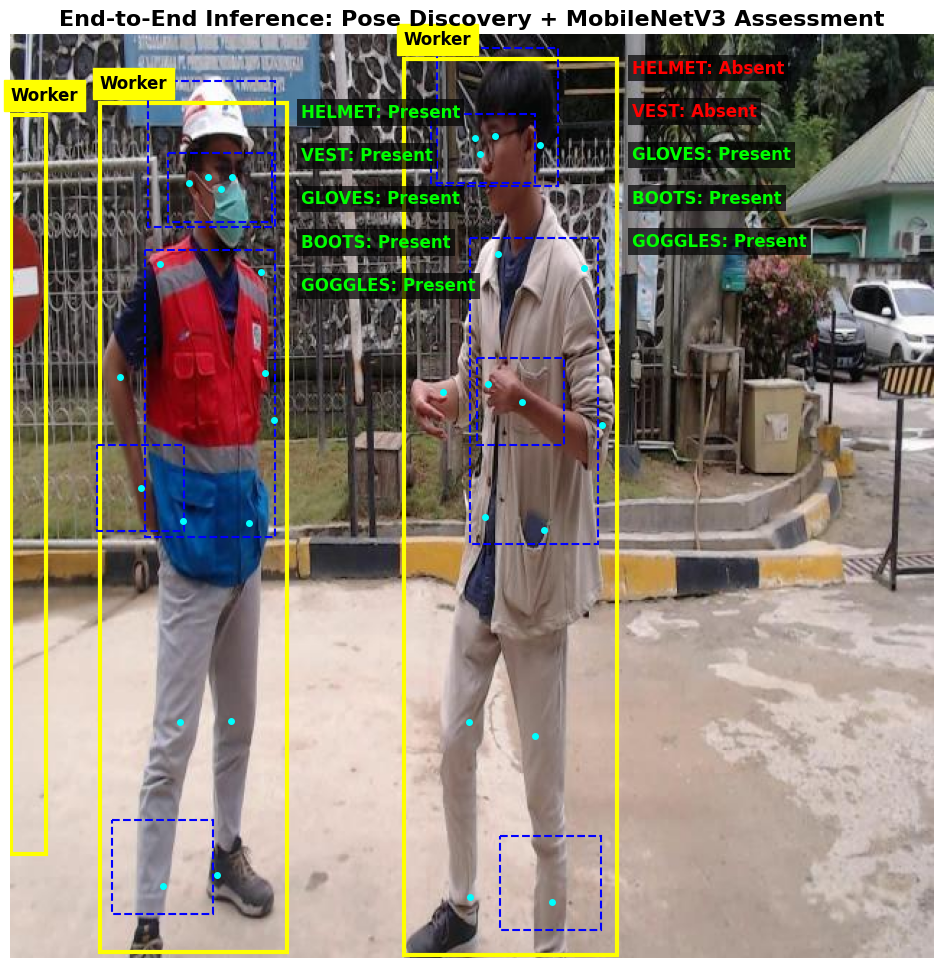

In [15]:
import random
import matplotlib.patches as patches
from PIL import Image
import torchvision.transforms as T
import torch.nn.functional as F

print("Loading MobileNet Classifiers...")
heads = ['helmet', 'vest', 'gloves', 'boots', 'goggles']
models = {}
for h in heads:
    m = mobilenet_v3_small(weights=None)
    in_features = m.classifier[3].in_features
    m.classifier[3] = nn.Linear(in_features, 3)
    pth = MODEL_DIR / f'{h}_head.pth'
    if pth.exists():
        m.load_state_dict(torch.load(pth, map_location=device))
    m.to(device).eval()
    models[h] = m

pose_model = YOLO('yolov8n-pose.pt')
val_imgs = list((DATASET_ROOT / 'images' / 'test').glob('*.jpg'))
if not val_imgs:
    val_imgs = list((DATASET_ROOT / 'images' / 'train').glob('*.jpg'))
if not val_imgs:
    print("No images found for inference test.")
else:
    test_img = random.choice(val_imgs)
    img = cv2.imread(str(test_img))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    
    results = pose_model.predict(img, verbose=False, device='cpu')[0]
    
    fig, ax = plt.subplots(1, 1, figsize=(14, 12))
    ax.imshow(img_rgb)
    ax.axis('off')
    ax.set_title("End-to-End Inference: Pose Discovery + MobileNetV3 Assessment", fontsize=16, fontweight='bold')
    
    if results.boxes is not None and len(results.boxes) > 0:
        for i, box in enumerate(results.boxes):
            # Draw Worker box
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
            rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=3, edgecolor='yellow', facecolor='none')
            ax.add_patch(rect)
            ax.text(x1, max(0, y1-10), 'Worker', color='black', backgroundcolor='yellow', fontsize=12, weight='bold')
            
            if results.keypoints is not None and len(results.keypoints) > i:
                kp = results.keypoints.data[i].cpu().numpy()
                for k in kp:
                    if k[2] > 0.5:
                        ax.plot(k[0], k[1], 'o', color='cyan', markersize=4)
                
                rois = {}
                
                # Helmet
                head_kps = [k for k in kp[:5] if k[2] > 0.5]
                if head_kps:
                    cx, cy = np.mean([k[0] for k in head_kps]), np.mean([k[1] for k in head_kps])
                    h_sz = max(30.0, abs(kp[6][0] - kp[5][0]) * 0.45) if kp[5][2] > 0.5 and kp[6][2] > 0.5 else 40.0
                    rois['helmet'] = [cx-h_sz*1.4, cy-h_sz*2.2, cx+h_sz*1.4, cy+h_sz*1.0]
                
                # Vest
                if all(k[2] > 0.5 for k in [kp[5], kp[6], kp[11], kp[12]]):
                    pad = 10
                    rois['vest'] = [min(kp[5][0], kp[6][0], kp[11][0], kp[12][0])-pad, min(kp[5][1], kp[6][1])-pad, max(kp[5][0], kp[6][0], kp[11][0], kp[12][0])+pad, max(kp[11][1], kp[12][1])+pad]
                
                # Gloves
                wk = kp[9] if kp[9][2] > kp[10][2] else kp[10]
                if wk[2] > 0.5: rois['gloves'] = [wk[0]-30, wk[1]-30, wk[0]+30, wk[1]+30]
                
                # Boots
                ak = kp[15] if kp[15][2] > kp[16][2] else kp[16]
                if ak[2] > 0.5: rois['boots'] = [ak[0]-35, ak[1]-45, ak[0]+35, ak[1]+20]
                
                # Goggles
                eyes = [k for k in (kp[1], kp[2], kp[0]) if k[2] > 0.5]
                if len(eyes) >= 1:
                    cxe, cye = sum(k[0] for k in eyes) / len(eyes), sum(k[1] for k in eyes) / len(eyes)
                    gsz = max(15.0, 24.0)
                    rois['goggles'] = [cxe-gsz*1.5, cye-gsz*0.8, cxe+gsz*1.5, cye+gsz*1.2]
                
                val_transform = transforms.Compose([ transforms.ToPILImage(), transforms.Resize((224,224)), transforms.ToTensor(), transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]) ])
                y_off = 10
                for h_name, roi in rois.items():
                    rx1, ry1, rx2, ry2 = max(0, int(roi[0])), max(0, int(roi[1])), min(w, int(roi[2])), min(h, int(roi[3]))
                    if rx2 <= rx1 or ry2 <= ry1: continue
                    
                    ax.add_patch(patches.Rectangle((rx1, ry1), rx2-rx1, ry2-ry1, linewidth=1.5, edgecolor='blue', linestyle='--', facecolor='none'))
                    
                    crop = img_rgb[ry1:ry2, rx1:rx2]
                    if crop.size > 0:
                        img_t = val_transform(crop).unsqueeze(0).to(device)
                        out = models[h_name](img_t)
                        pred_idx = out.argmax(dim=1).item()
                        stat = 'Present' if pred_idx == 2 else 'Absent'
                        col = 'lime' if pred_idx == 2 else 'red'
                        
                        # If model isn't trained (random weights), it's just defaulting, but visualization proves crops work.
                        ax.text(x2 + 10, max(0, y1 + y_off), f'{h_name.upper()}: {stat}', color=col, fontsize=12, weight='bold', bbox=dict(facecolor='black', alpha=0.7, edgecolor='none', pad=3))
                        y_off += 30
    plt.show()